In [16]:
# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import matplotlib.pyplot as plt
import pandas as pd
from cns.process import group_samples, add_total_cn
from cns.analyze import fig_lines, fig_dots,  fig_dots, plot_dots
from cns.data_utils import  main_load, load_samples_out, save_cns_fig, select_cns_by_type
from cns.utils import calc_mid

plt.rcParams.update({'font.size': 12})

In [ ]:
tcga_samples = load_samples_out("TCGA_hg19_samples.tsv", use_filter=True)
len(tcga_samples[tcga_samples["type"] == 'LUAD']) 

458

In [19]:
samples_df, cns_df = main_load("1MB")
datasets = samples_df["source"].unique()

In [20]:
def first_name(name):
    return name.split("_")[0]

In [21]:
datasets = ["PCAWG", "TRACERx", "TCGA_hg19"]
luad_dict = { f'{first_name(k)} LUAD': select_cns_by_type(cns_df, samples_df.query(f"source == '{k}'"), "LUAD") for k in datasets }
lusc_dict = { f'{first_name(k)} LUSC': select_cns_by_type(cns_df, samples_df.query(f"source == '{k}'"), "LUSC") for k in datasets }
all_dict = luad_dict | lusc_dict
means_single = pd.concat([add_total_cn(group_samples(v, group_name=k)) for k, v in all_dict.items()])

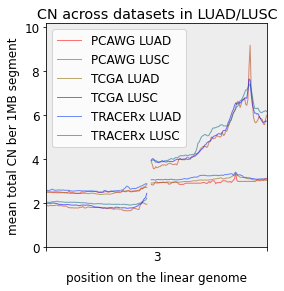

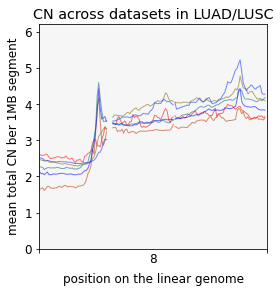

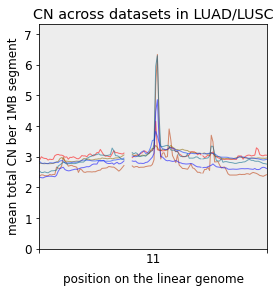

In [31]:
colors = ["#FF0000", "#BB3300", "#886600", "#0000FF", "#0033FF", "#006688"]
chroms = ["chr3", "chr8", "chr11"]
for chrom in chroms:
	fig, ax = fig_lines(means_single.query(f"chrom == '{chrom}'"), cn_columns="total_cn", colors=colors)
	ax.set_ylabel("mean total CN ber 1MB segment")
	ax.set_title("CN across datasets in LUAD/LUSC")
	if chrom == "chr3":
		ax.legend(loc='upper left')
	else:
		# disable legend
		ax.legend().set_visible(False)
	save_cns_fig(f"fig_LUAD_LUSC_single_{chrom}")

In [37]:
# pearson correlation of means_single[0]["total_cn"] and means_single[1]["total_cn"]
datasets = ["PCAWG", "TRACERx", "TCGA"]
print("Correlations on 1 Mb segments between datasets")
correlations = []
for ctype in ["LUAD", "LUSC"]:
    for i in datasets:
        for j in datasets:
            first = f"{i} {ctype}"
            second = f"{j} {ctype}"
            corr = means_single.query(f"sample_id == '{i} {ctype}'")["total_cn"].corr(
                means_single.query(f"sample_id == '{j} {ctype}'")["total_cn"], method="pearson"
            )
            correlations.append((i, j, ctype, corr))

corr_df = pd.DataFrame(correlations, columns=["first", "second", "type", "corr"])
for ctype in ["LUAD", "LUSC"]:
    filtered_df = corr_df[corr_df['type'] == ctype]
    pivot_df = filtered_df.pivot(index='first', columns='second', values='corr')
    print(f"Correlation matrix for {ctype}:")
    print(pivot_df)

Correlations on 1 Mb segments between datasets
Correlation matrix for LUAD:
second      PCAWG      TCGA   TRACERx
first                                
PCAWG    1.000000  0.832256  0.766978
TCGA     0.832256  1.000000  0.811373
TRACERx  0.766978  0.811373  1.000000
Correlation matrix for LUSC:
second      PCAWG      TCGA   TRACERx
first                                
PCAWG    1.000000  0.965726  0.885116
TCGA     0.965726  1.000000  0.892662
TRACERx  0.885116  0.892662  1.000000


In [38]:
_, cosmic_df = main_load("COSMIC")
cosmic_group = group_samples(cosmic_df)

In [ ]:
cosmic_lusc_group = add_total_cn(group_samples(select_cns_by_type(cosmic_df, samples_df, "LUSC"), group_name="COSMIC LUSC"))
cosmic_luad_group = add_total_cn(group_samples(select_cns_by_type(cosmic_df, samples_df, "LUAD"), group_name="COSMIC LUAD"))
cosmic_both = pd.concat([cosmic_lusc_group, cosmic_luad_group])

In [40]:
# Plot the top attributions
cosmic_lusc_group.sort_values("total_cn", ascending=False).head()

,chrom,start,end,name,major_cn,minor_cn,sample_id,total_cn
482,chr3,181429713,181432221,SOX2,5.761044,1.800201,COSMIC LUSC,7.561245
481,chr3,178865901,178957881,PIK3CA,5.122490,1.792169,COSMIC LUSC,6.914659
480,chr3,176737142,176915261,TBL1XR1,4.956827,1.794177,COSMIC LUSC,6.751004
483,chr3,185000728,185206885,MAP3K13,4.811245,1.726908,COSMIC LUSC,6.538153
484,chr3,185361526,185542844,IGF2BP2,4.729920,1.716867,COSMIC LUSC,6.446787


In [41]:
# Plot the neighbours of SOX2
cosmic_lusc_group.query("chrom == 'chr3'").query("start > 175000000").head()

,chrom,start,end,name,major_cn,minor_cn,sample_id,total_cn
480,chr3,176737142,176915261,TBL1XR1,4.956827,1.794177,COSMIC LUSC,6.751004
481,chr3,178865901,178957881,PIK3CA,5.122490,1.792169,COSMIC LUSC,6.914659
482,chr3,181429713,181432221,SOX2,5.761044,1.800201,COSMIC LUSC,7.561245
483,chr3,185000728,185206885,MAP3K13,4.811245,1.726908,COSMIC LUSC,6.538153
484,chr3,185361526,185542844,IGF2BP2,4.729920,1.716867,COSMIC LUSC,6.446787


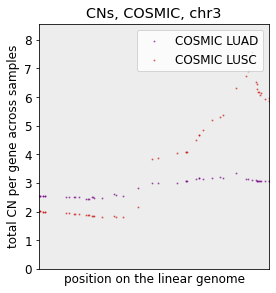

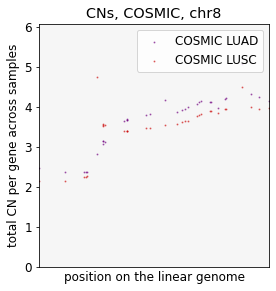

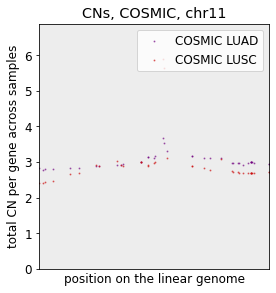

In [ ]:
for chrom in chroms:
    fig, ax = fig_dots(cosmic_both.query(f'chrom == "{chrom}"'), cn_columns="total_cn")

    ax.set_ylabel("total CN per gene across samples")
    plt.title(f"CNs, COSMIC, {chrom}")
    save_cns_fig(f"fig_COSMIC_IG_att_{chrom}")

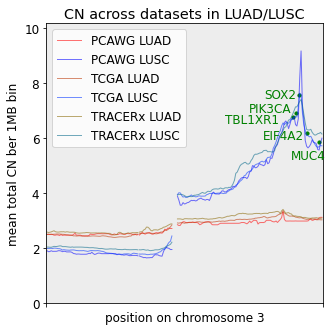

In [62]:
from cns import hg19
colors = ["#FF0000", "#0000FF", "#BB3300", "#0033FF", "#886600", "#006688"]
fig, ax = fig_lines(means_single.query("chrom == 'chr3'"), cn_columns="total_cn", colors=colors)
ax.set_ylabel("mean total CN ber 1MB bin")
ax.set_title("CN across datasets in LUAD/LUSC")
ax.legend(loc='upper left')
fig.set_size_inches(5, 5) 
# erase x labels

offsets = {
    'EIF4A2': (-.2, -.1),
    'SOX2': (-.2, 0),
    'TBL1XR1': (-1, -.1),
    'PIK3CA': (-.3, .15),
    "MUC4": (.5, -.5)
}

for i, row in cosmic_lusc_group.iterrows():
    if row['name'] in ['EIF4A2', 'SOX2', 'TBL1XR1', 'PIK3CA', "MUC4"]:
        mid = calc_mid(row) + hg19.chr_starts["chr3"]
        plt.scatter(mid, row['total_cn'], color='green', s=10)
        name = row['name']
        x, y = offsets[name]
        plt.text(mid + x*10**7, row['total_cn'] + y, name, color="green", size=12, ha='right', va='center')

ax.set_xticklabels([], minor=True)
ax.set_xlabel("position on chromosome 3", labelpad=-12)

save_cns_fig(f"fig_COSMIC_lines_IG_att_chr3")